In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import torch
import gc
from IPython.display import display

ds_name = 'real_NCT00981058_inject'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
proj_name = 'SurvSurfBenchmark_NCT00981058_inject'
g_resol = 1
t_resol = 7
g_max = 5
max_time = 140
split='test'
DIR_OUTPUT = './output_fig/supp'

In [2]:
DEVICE = 'cpu'
if DEVICE == 'gpu':
    assert torch.cuda.is_available()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
else:
    device = 'cpu'

## Import and instantiate model

In [3]:
from dataset_NCT00981058 import DataModuleNCT00981058, DatasetNCT00981058

In [4]:
ds = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False,
)
df_obs = ds._get_df_Xy_trans_obs()
df_true_prob = ds._get_df_Xy_true_prob()
df_true_prob.loc[
    df_true_prob[ds.colname_g] == 6,:
].head()

,subject,duration,g_max_by_time,event_observed,weight,feat__AGE,feat__BLOOD AND LYMPHATIC SYSTEM DISORDERS,feat__BMIBL,feat__BSABL,feat__Body Surface Area (m^2),...,feat__SMKB_Smoker (all others),feat__SOCIAL CIRCUMSTANCES,feat__SURGICAL AND MEDICAL PROCEDURES,feat__Systolic Blood Pressure (mmHg),feat__Temperature (°C),feat__VASCULAR DISORDERS,"feat__WBCCAT1_> 11,000 µl (11 x 10^9/L)",feat__Weight (kg),feat__traj_clust,is_t_trans


In [5]:
df_true_prob['g_max_by_time'].value_counts()

g_max_by_time
1    2400
2    2400
3    2400
4    2400
5    2400
Name: count, dtype: int64

In [6]:
import pickle
def pred_from_sksurv_joint(run_id, proj_name, split='val'):

    if 'more_g' in run_id:
        path_pickle = f'./sksurv_models/more_g/{proj_name}/Joint/{run_id}.pickle'
    else:
        path_pickle = f'./sksurv_models/{proj_name}/Joint/{run_id}.pickle'
    with open(path_pickle, 'rb') as f:
        model = pickle.load(f)
    
    ds = DatasetNCT00981058(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        t_resol=t_resol,
        split=split, 
        mode='first_cross_obs_only', 
        separate_g_from_feats=False,
    )
    df_obs = ds._get_df_Xy_trans_obs()
    df_true_prob = ds._get_df_Xy_true_prob()
    assert (
        df_true_prob.groupby(['subject',ds.colname_g]).apply(
            lambda x: tuple(x['duration']),
            include_groups=False
        )
    ).nunique() == 1


    cols_X = np.r_[[ds.colname_g], df_obs.columns[df_obs.columns.str.startswith('feat')]]      

    df_val_results_obs = []
    df_val_results_grid = []
    for g, df_obs_g in df_obs.groupby(ds.colname_g):
        if g > ds.g_max:
            continue
        df_true_prob_g = df_true_prob.loc[
            df_true_prob[ds.colname_g] == g,:
        ]

        n_unique_time_per_subj = (
            df_true_prob_g.groupby(['subject']).apply(
                lambda x: tuple(x['duration'].sort_values()),
                include_groups=False
            )
        ).nunique()
        assert n_unique_time_per_subj == 1, n_unique_time_per_subj
        
        curvs = model.predict_survival_function(df_obs_g[cols_X])
                
        
        for subj, curv in zip(df_obs_g['subject'], curvs):
            obs_g_subj = df_obs_g.loc[df_obs_g['subject'] == subj,:]
            assert obs_g_subj.shape[0] == 1
            obs_g_subj = obs_g_subj.iloc[0,:]
            t = obs_g_subj['duration']
            truth = obs_g_subj['event_observed']
            if t > curv.x.max():
                pred = curv(curv.x.max())
            else:
                pred = curv(t)
            row = {
                'subj':subj,
                'g':g,
                't':t,
                'pred':1-pred,
                'truth':truth
            }
            df_val_results_obs.append(row)

    for g, df_true_prob_g in df_true_prob.groupby(ds.colname_g):   
        df_true_prob_g_tless = df_true_prob_g.drop(columns=['duration','event_observed']).drop_duplicates()
        assert df_true_prob_g_tless['subject'].value_counts().max() == 1
        curvs = model.predict_survival_function(df_true_prob_g_tless[cols_X])

        for subj, curv in zip(df_true_prob_g_tless['subject'], curvs):
            df_val_subj_g = pd.DataFrame()
            df_true_prob_subj_g = df_true_prob_g.loc[
                df_true_prob_g['subject'] == subj,:
            ].sort_values('duration')
            t_grid = df_true_prob_subj_g['duration']
            t_grid_in_range = t_grid[t_grid <= curv.x.max()]
            t_grid_extrap = t_grid[t_grid > curv.x.max()]
            pred_prob_at_time_grid = curv(t_grid_in_range)
            pred_prob_at_time_grid = np.r_[pred_prob_at_time_grid, [pred_prob_at_time_grid[-1]]*t_grid_extrap.size]

            df_val_subj_g['t'] = t_grid
            df_val_subj_g['subj'] = subj
            df_val_subj_g['g'] = g
            df_val_subj_g['pred'] = 1-pred_prob_at_time_grid
            df_val_subj_g['truth'] = df_true_prob_subj_g['event_observed']
            df_val_results_grid.append(df_val_subj_g)

    out_dfs = dict()
    out_dfs['obs'] = pd.DataFrame(df_val_results_obs)
    out_dfs['true_prob'] = pd.concat(df_val_results_grid)
    return out_dfs, f'Joint_{model.__class__.__name__}'

In [7]:
def pred_from_DeepHit(run_id, proj_name, split='val'):
    import wandb
    from model_factory_deephit import LitModelDeepHit
    torch.set_float32_matmul_precision('medium')

    api = wandb.Api()
    # artifact = api.artifact(f'yichenchen-wings/{proj_name}/model-{run_id}:v0', type='model')
    # checkpoint_dir = artifact.download()
    checkpoint_dir = f'/home/yc366/repos/survsurf_benchmark/runtime_results/{proj_name}/{run_id}/checkpoints/'
    os.listdir(checkpoint_dir)[0]
    #path_checkpoint = os.path.join(checkpoint_dir, 'model.ckpt')
    path_checkpoint = os.path.join(checkpoint_dir, os.listdir(checkpoint_dir)[0])
    model_lit = LitModelDeepHit.load_from_checkpoint(path_checkpoint)
    
    datamodule = DataModuleNCT00981058(
        df_dir=ds_df_dir, 
        ds_name=ds_name, 
        g_resol=g_resol, 
        t_resol=t_resol,
        separate_g_from_feats=False, 
        train_mode='first_cross_obs_only',
        eval_mode='true_probs_grid',
        batch_size=100, 
        num_workers=4)
    datamodule.setup(stage=split)
    if 'val' in split:
        dataloader_obs, dataloader_true_prob = datamodule.val_dataloader()
    if 'test' in split:
        dataloader_obs, dataloader_true_prob = datamodule.test_dataloader()

    with torch.no_grad():
        torch.cuda.empty_cache()
    gc.collect()

    model_loaded_core = model_lit.model
    model_loaded_core = model_loaded_core.to(device)
    model_loaded_core.eval()

    t_size = model_lit.loss_brier.t_size
    t_res = model_lit.loss_brier.t_res

    out_dfs = dict()
    for key, dataloader in [
        ('obs', dataloader_obs),
        ('true_prob', dataloader_true_prob)
    ]:
        
        out_dfs = dict()
    for key, dataloader in [
        ('obs', dataloader_obs),
        ('true_prob', dataloader_true_prob)
    ]:
        subjs = []
        g = []
        t = []
        pred = []
        truth = []
        with torch.no_grad():
            for batch_, (subj, xs, ts, ys, weight, _) in enumerate(dataloader):
                xs, ts, ys = xs.to(device), ts.to(device), ys.to(device)
                out = model_loaded_core.forward_cif(xs)
                assert out.dim() == 3, f'found output with n dim = {out.dim()}, expecting a 3d tensor.'
                assert out.shape[1] == 1, f'found output with second dim = {out.shape[1]}, expecting 1.'
                out = out.reshape(out.shape[0], out.shape[-1])

                t_matrix = ts.repeat(1, t_size)
                
                t_matrix_ref = torch.linspace(0, t_size-1, steps=t_size)*t_res
                t_matrix_ref = t_matrix_ref.repeat(xs.shape[0], 1)

                selector_where_t = torch.logical_and(t_matrix_ref >= t_matrix,  t_matrix_ref < (t_matrix + t_res))
                assert torch.all(selector_where_t.sum(dim=-1) == 1)
                out = out[selector_where_t].reshape(xs.shape[0])

                subjs += list(subj)
                g += list(datamodule.g_max*xs.cpu().numpy()[:,-1])
                t += list(ts.cpu().numpy()[:,0])
                truth += list(ys.cpu().numpy()[:,0])
                pred += list(out.cpu().numpy())


        pred = np.array(pred)
        truth = np.array(truth)
        df_val_results = pd.DataFrame()
        df_val_results['subj'] = subjs
        df_val_results['g'] = g
        df_val_results['t'] = t
        df_val_results['pred'] = pred
        df_val_results['truth'] = truth
        for col in ['pred', 'truth']:
            df_val_results[col] = df_val_results[col].astype(float)
        out_dfs[key] = df_val_results
    return out_dfs, model_loaded_core.__class__.__name__


In [8]:


ds_train = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split='train', 
    mode='true_probs_grid', 
    separate_g_from_feats=False
)
ds_val = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split='val', 
    mode='true_probs_grid', 
    separate_g_from_feats=False
)
ds_test = DatasetNCT00981058(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    t_resol=t_resol,
    split='test', 
    mode='true_probs_grid', 
    separate_g_from_feats=False
)

In [9]:
ds_test._get_df_Xy_trans_obs()['g_max_by_time'].value_counts()

g_max_by_time
2.0    66
1.0    65
3.0    64
4.0    45
5.0    17
6.0     2
Name: count, dtype: int64

In [10]:
df_all_out = []
for run_id, pred_fun, descriptor in [

    ('8n2sgazv',pred_from_DeepHit,'LossSumo'),
    ('zxvcnylw',pred_from_DeepHit,'LossSumo'),
    ('sb5p2jxu',pred_from_DeepHit,'LossSumo'),
    ('34citj9l',pred_from_DeepHit,'LossSumo'),
    ('7mvbcrq7',pred_from_DeepHit,'LossSumo'),

    ('tcjqptb2',pred_from_DeepHit,'LossSumo(more g)'),
    ('xeiqaiin',pred_from_DeepHit,'LossSumo(more g)'),
    ('n4wh25m1',pred_from_DeepHit,'LossSumo(more g)'),
    ('fnvw90zb',pred_from_DeepHit,'LossSumo(more g)'),
    ('99dnj00b',pred_from_DeepHit,'LossSumo(more g)'),

    ('Joint_GradientBoostingSurvivalAnalysis_seed_10',pred_from_sksurv_joint, 'standard'),
    ('Joint_GradientBoostingSurvivalAnalysis_seed_20',pred_from_sksurv_joint, 'standard'),
    ('Joint_GradientBoostingSurvivalAnalysis_seed_30',pred_from_sksurv_joint, 'standard'),
    ('Joint_GradientBoostingSurvivalAnalysis_seed_40',pred_from_sksurv_joint, 'standard'),
    ('Joint_GradientBoostingSurvivalAnalysis_seed_50',pred_from_sksurv_joint, 'standard'),

    ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_30',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_40',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_GradientBoostingSurvivalAnalysis_more_g_seed_50',pred_from_sksurv_joint, 'standard(more g)'),

    ('Joint_RandomSurvivalForest_seed_10',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_20',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_30',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_40',pred_from_sksurv_joint, 'standard'),
    ('Joint_RandomSurvivalForest_seed_50',pred_from_sksurv_joint, 'standard'),

    ('Joint_RandomSurvivalForest_more_g_seed_10',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_20',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_30',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_40',pred_from_sksurv_joint, 'standard(more g)'),
    ('Joint_RandomSurvivalForest_more_g_seed_50',pred_from_sksurv_joint, 'standard(more g)'),
]:
    out_model, model_name = pred_fun(run_id=run_id, proj_name=proj_name, split=split)
    df_out = out_model['true_prob']
    df_out['model_type'] = model_name
    df_out['id'] = run_id
    df_out['is_more_g'] = ('more g' in descriptor)
    df_all_out.append(df_out)
    print(f'finished processing {run_id}')
df_all_out = pd.concat(df_all_out)

/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


finished processing 8n2sgazv


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


finished processing zxvcnylw


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


...

finished processing n4wh25m1


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


finished processing fnvw90zb


/home/yc366/miniconda3/envs/env_survsurf_benchmark/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


finished processing 99dnj00b
finished processing Joint_GradientBoostingSurvivalAnalysis_seed_10
finished processing Joint_GradientBoostingSurvivalAnalysis_seed_20
finished processing Joint_GradientBoostingSurvivalAnalysis_seed_30
finished processing Joint_GradientBoostingSurvivalAnalysis_seed_40
finished processing Joint_GradientBoostingSurvivalAnalysis_seed_50
finished processing Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10
finished processing Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20
finished processing Joint_GradientBoostingSurvivalAnalysis_more_g_seed_30
finished processing Joint_GradientBoostingSurvivalAnalysis_more_g_seed_40
finished processing Joint_GradientBoostingSurvivalAnalysis_more_g_seed_50
finished processing Joint_RandomSurvivalForest_seed_10
finished processing Joint_RandomSurvivalForest_seed_20
finished processing Joint_RandomSurvivalForest_seed_30
finished processing Joint_RandomSurvivalForest_seed_40
finished processing Joint_RandomSurvivalForest

In [11]:
df_all_out.head()

,subj,g,t,pred,truth,model_type,id,is_more_g
0,b'014-7882',1.0,0.0,0.002059,0.0,DeepHit,8n2sgazv,False
1,b'014-7882',1.0,7.0,0.431408,1.0,DeepHit,8n2sgazv,False
2,b'014-7882',1.0,14.0,0.584062,1.0,DeepHit,8n2sgazv,False
3,b'014-7882',1.0,21.0,0.619729,1.0,DeepHit,8n2sgazv,False
4,b'014-7882',1.0,28.0,0.721180,1.0,DeepHit,8n2sgazv,False


In [12]:
df_mean_pred = df_all_out.groupby(
    ['subj','g','t','model_type','is_more_g']
)['pred'].mean().rename('seed_mean_pred').reset_index()

df_truth = df_all_out[['subj','g','t','truth']].drop_duplicates()


In [13]:
df_comparsion_all = []
for model, df_model in df_mean_pred.groupby('model_type'):
    df_standard = df_model.loc[~df_model['is_more_g'],:].copy().drop(columns=['is_more_g'])
    df_more_g = df_model.loc[df_model['is_more_g'],:].copy().drop(columns=['is_more_g'])
    assert df_standard.shape == df_more_g.shape
    df_comparison = df_standard.merge(df_more_g, on=['subj','g','t','model_type'], suffixes=('_less_g', '_more_g'))
    assert df_comparison.shape[0] == df_standard.shape[0]
    df_comparsion_all.append(df_comparison)
df_comparsion_all = pd.concat(df_comparsion_all)
df_comparsion_all = df_comparsion_all.merge(df_truth, on=['subj','g','t'])
df_comparsion_all['model_type'] = df_comparsion_all['model_type'].replace({'DeepHit':'DeepHit-SUMO'})
df_comparsion_all['model_type'] = df_comparsion_all['model_type'].apply(lambda x: x.split('_')[-1])

df_comparsion_all.head()

,subj,g,t,model_type,seed_mean_pred_less_g,seed_mean_pred_more_g,truth
0,b'014-7882',1.0,0.0,DeepHit-SUMO,0.001930,0.003204,0.0
1,b'014-7882',1.0,7.0,DeepHit-SUMO,0.442499,0.383277,1.0
2,b'014-7882',1.0,14.0,DeepHit-SUMO,0.595758,0.517638,1.0
3,b'014-7882',1.0,21.0,DeepHit-SUMO,0.630700,0.550504,1.0
4,b'014-7882',1.0,28.0,DeepHit-SUMO,0.734351,0.640063,1.0


In [14]:
df_comparsion_all['pred_diff_more_g_vs_less_g'] = df_comparsion_all['seed_mean_pred_more_g'] - df_comparsion_all['seed_mean_pred_less_g']
df_comparsion_all['err_mean_pred_less_g'] = df_comparsion_all['truth'] != (df_comparsion_all['seed_mean_pred_less_g'] > 0.5)
df_comparsion_all.loc[df_comparsion_all['truth'].isna(), 'err_mean_pred_less_g'] = np.nan
df_comparsion_all['FN_mean_pred_less_g'] = df_comparsion_all['truth']*(df_comparsion_all['seed_mean_pred_less_g'] < 0.5)
df_comparsion_all.loc[df_comparsion_all['truth'].isna(), 'FN_mean_pred_less_g'] = np.nan
df_comparsion_all['err_mean_pred_more_g'] = df_comparsion_all['truth'] != (df_comparsion_all['seed_mean_pred_more_g'] > 0.5)
df_comparsion_all.loc[df_comparsion_all['truth'].isna(), 'err_mean_pred_more_g'] = np.nan
df_comparsion_all['FN_mean_pred_more_g'] = df_comparsion_all['truth']*(df_comparsion_all['seed_mean_pred_more_g'] < 0.5)
df_comparsion_all.loc[df_comparsion_all['truth'].isna(), 'FN_mean_pred_more_g'] = np.nan

df_comparsion_all = df_comparsion_all.loc[df_comparsion_all['t'] <= max_time,:]
df_comparsion_all.head()


/tmp/ipykernel_24334/1408833042.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_comparsion_all.loc[df_comparsion_all['truth'].isna(), 'err_mean_pred_less_g'] = np.nan
/tmp/ipykernel_24334/1408833042.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_comparsion_all.loc[df_comparsion_all['truth'].isna(), 'err_mean_pred_more_g'] = np.nan


,subj,g,t,model_type,seed_mean_pred_less_g,seed_mean_pred_more_g,truth,pred_diff_more_g_vs_less_g,err_mean_pred_less_g,FN_mean_pred_less_g,err_mean_pred_more_g,FN_mean_pred_more_g
0,b'014-7882',1.0,0.0,DeepHit-SUMO,0.001930,0.003204,0.0,0.001274,False,0.0,False,0.0
1,b'014-7882',1.0,7.0,DeepHit-SUMO,0.442499,0.383277,1.0,-0.059222,True,1.0,True,1.0
2,b'014-7882',1.0,14.0,DeepHit-SUMO,0.595758,0.517638,1.0,-0.078120,False,0.0,False,0.0
3,b'014-7882',1.0,21.0,DeepHit-SUMO,0.630700,0.550504,1.0,-0.080196,False,0.0,False,0.0
4,b'014-7882',1.0,28.0,DeepHit-SUMO,0.734351,0.640063,1.0,-0.094288,False,0.0,False,0.0


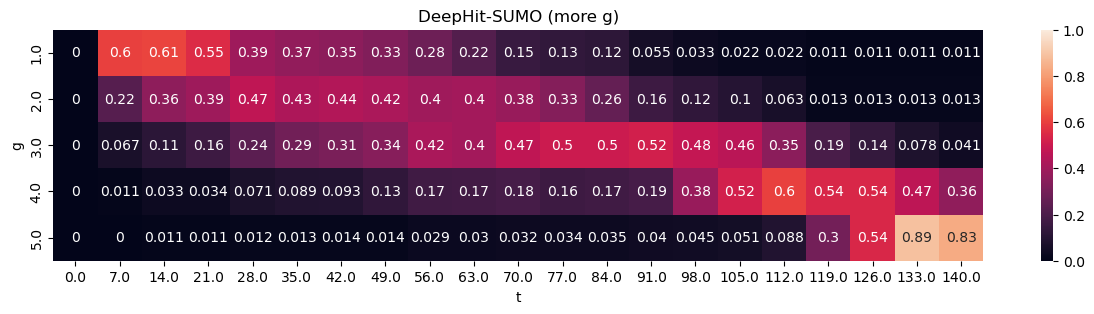

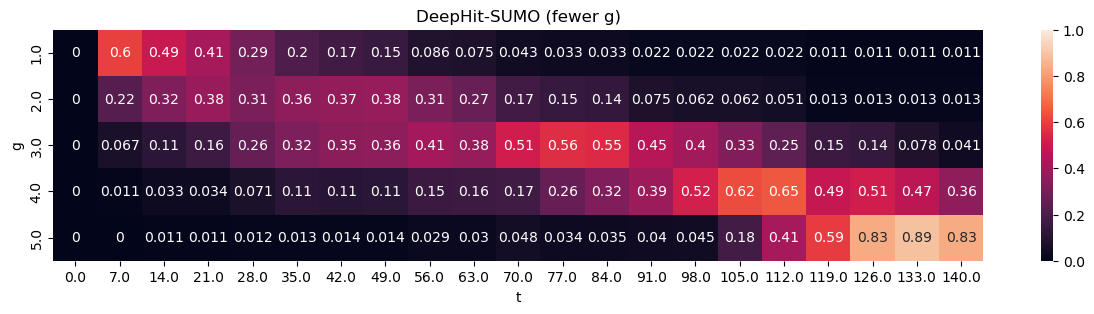

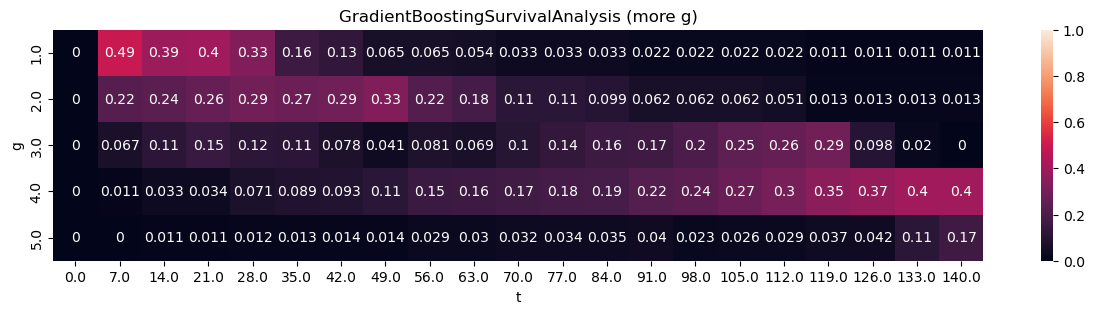

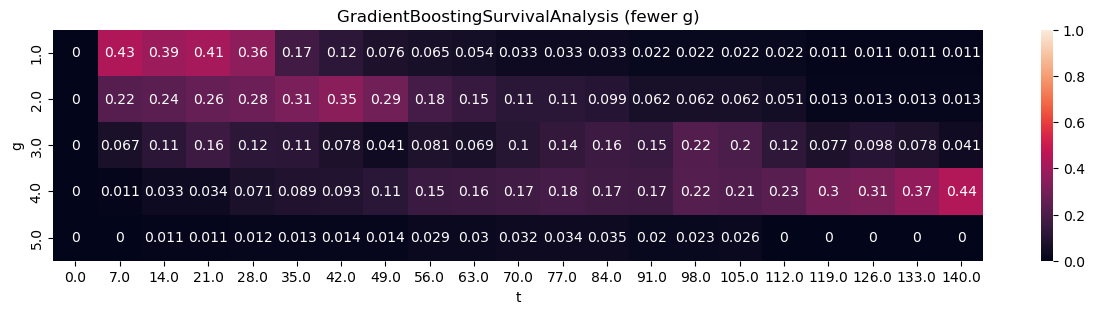

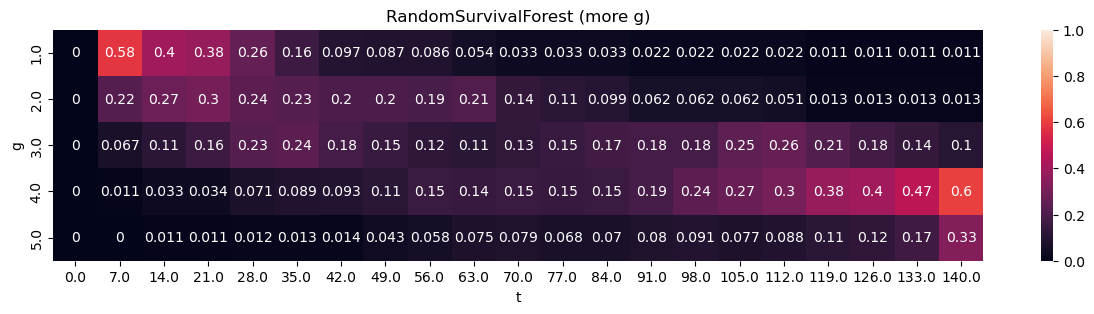

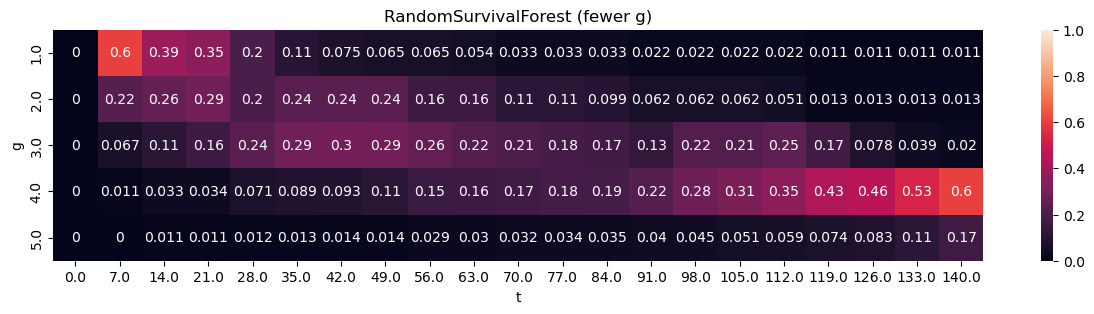

In [15]:
for grp, df_sub in df_comparsion_all.groupby('model_type'):
    df_to_plot = df_sub.groupby(['t','g'])['err_mean_pred_more_g'].apply(
        lambda x: x.mean()
    ).rename('err').reset_index().pivot(
        index='g',
        columns='t',
        values='err'
    )
    fig, ax = plt.subplots(1,1, figsize=(15, 3))
    sns.heatmap(df_to_plot, vmin=0,vmax=1, annot=True)
    ax.set(title=f'{grp} (more g)')

    df_to_plot = df_sub.groupby(['t','g'])['err_mean_pred_less_g'].apply(
        lambda x: x.mean()
    ).rename('err').reset_index().pivot(
        index='g',
        columns='t',
        values='err'
    )
    fig, ax = plt.subplots(1,1, figsize=(15, 3))
    sns.heatmap(df_to_plot, vmin=0,vmax=1, annot=True)
    ax.set(title=f'{grp} (fewer g)')


/tmp/ipykernel_24334/1491469843.py:4: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: x['fn'].sum()/x['truth'].sum()
/tmp/ipykernel_24334/1491469843.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_fn_pop_fract = df_fn.groupby(['g','t','id','model_type','is_more_g']).apply(


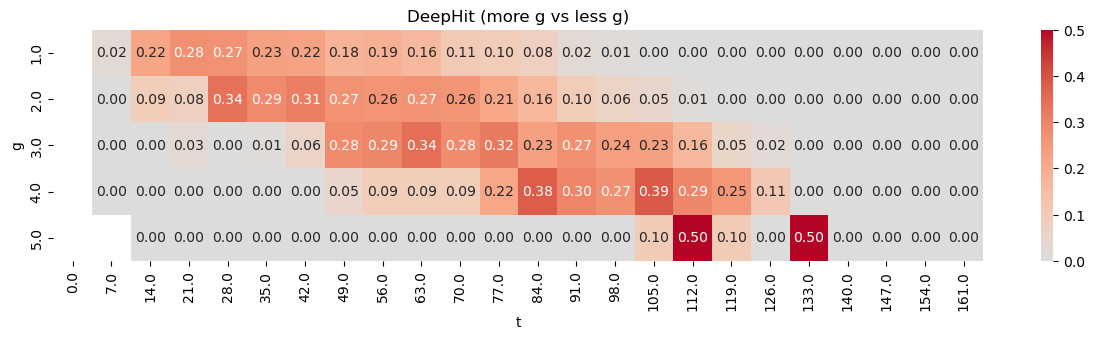

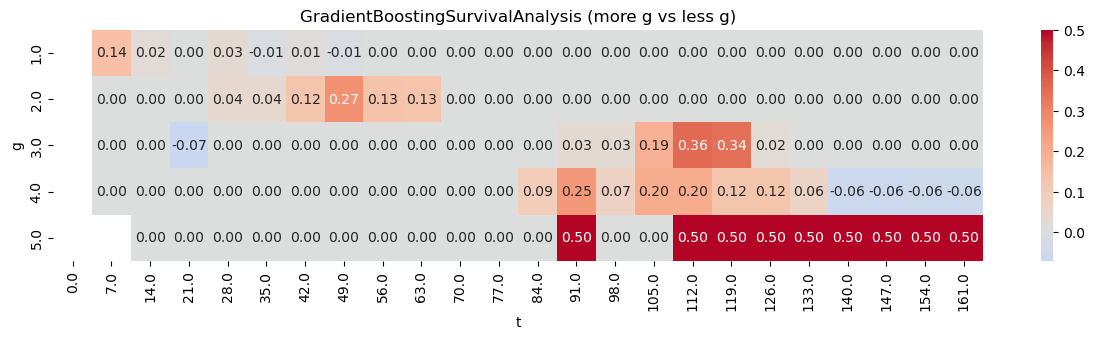

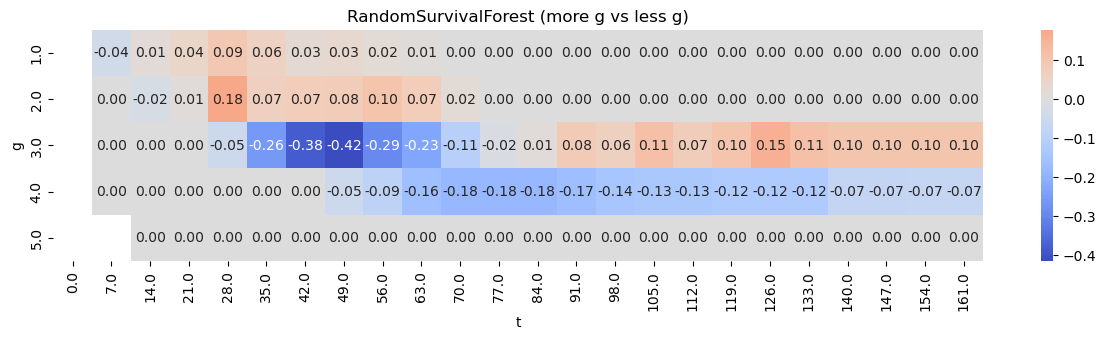

In [24]:
df_fn = df_all_out.copy()
df_fn['fn'] = (df_fn['pred'] < 0.5)*df_fn['truth']
df_fn_pop_fract = df_fn.groupby(['g','t','id','model_type','is_more_g']).apply(
    lambda x: x['fn'].sum()/x['truth'].sum()
).rename('perc_pos_as_fn').reset_index()
df_fn_pop_fract_mean_seeds = df_fn_pop_fract.groupby(
    ['g','t','model_type','is_more_g']
)['perc_pos_as_fn'].mean().rename('seed_mean_perc_pos_as_fn').reset_index()
df_fn_pop_fract_mean_seeds['model_type'] = df_fn_pop_fract_mean_seeds['model_type'].apply(lambda x: x.split('_')[-1])

for grp, df_sub in df_fn_pop_fract_mean_seeds.groupby('model_type'):
    df_to_plot = (
        df_sub.loc[df_sub['is_more_g'],:].pivot(
            index='g',
            columns='t',
            values='seed_mean_perc_pos_as_fn'
        ) - 
        df_sub.loc[~df_sub['is_more_g'],:].pivot(
            index='g',
            columns='t',
            values='seed_mean_perc_pos_as_fn'
        )
    )
    fig, ax = plt.subplots(1,1, figsize=(15, 3))
    sns.heatmap(df_to_plot, center=0, annot=True, fmt='.2f', cmap='coolwarm')
    ax.set(title=f'{grp} (more g vs less g)')

    fig.savefig(os.path.join(DIR_OUTPUT, f'mean_fract_pos_fn_more_g_vs_less_g_{grp}_{ds_name}.pdf'),bbox_inches="tight")

/tmp/ipykernel_24334/2035275468.py:4: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: x['fp'].sum()/x['truth'].sum()
/tmp/ipykernel_24334/2035275468.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_fp_pop_fract = df_fp.groupby(['g','t','id','model_type','is_more_g']).apply(


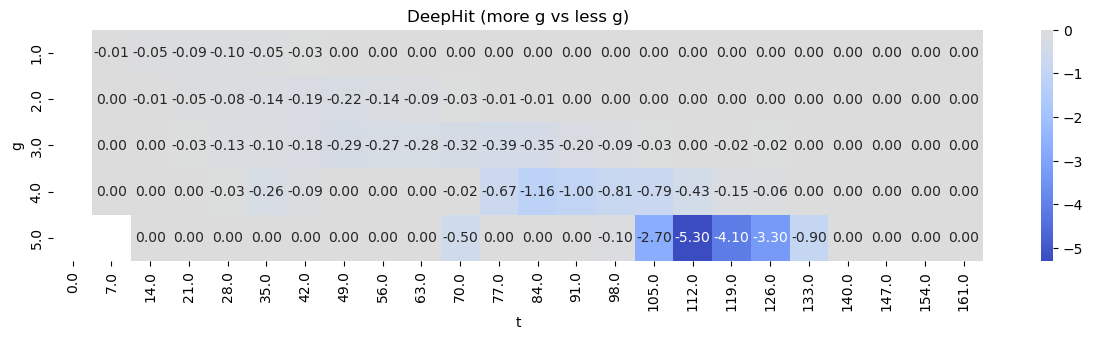

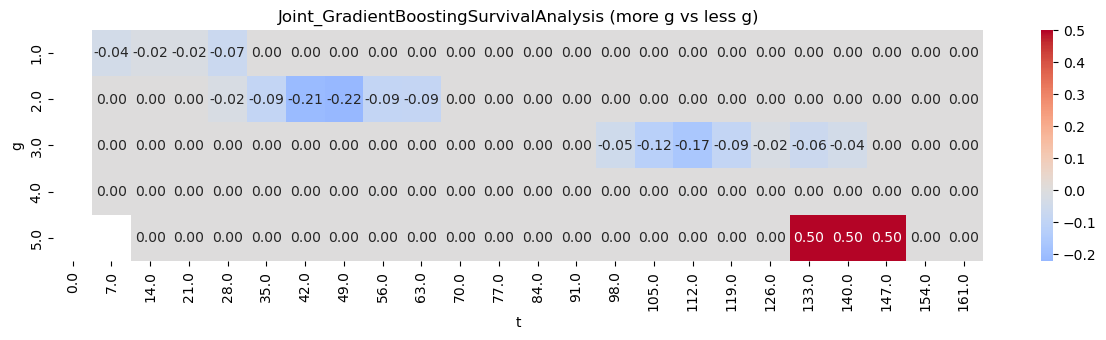

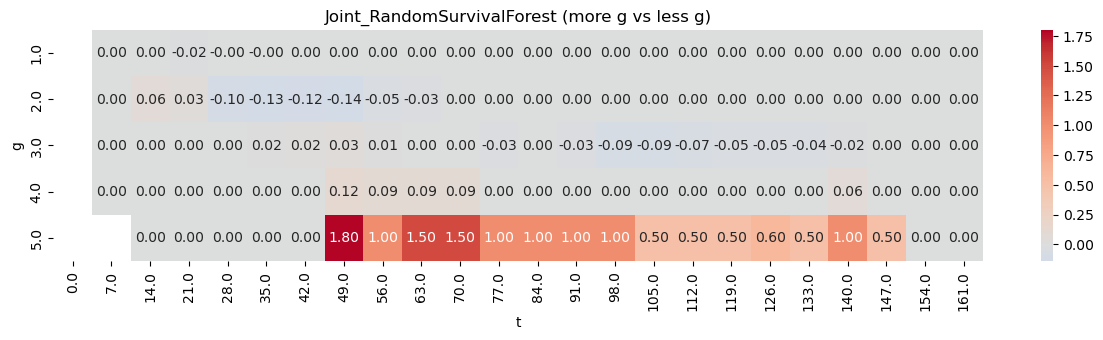

In [17]:
df_fp = df_all_out.copy()
df_fp['fp'] = (df_fp['pred'] > 0.5)*(1-df_fp['truth'])
df_fp_pop_fract = df_fp.groupby(['g','t','id','model_type','is_more_g']).apply(
    lambda x: x['fp'].sum()/x['truth'].sum()
).rename('perc_pos_as_fn').reset_index()
df_fp_pop_fract_mean_seeds = df_fp_pop_fract.groupby(
    ['g','t','model_type','is_more_g']
)['perc_pos_as_fn'].mean().rename('seed_mean_perc_pos_as_fp').reset_index()

for grp, df_sub in df_fp_pop_fract_mean_seeds.groupby('model_type'):
    df_to_plot = (
        df_sub.loc[df_sub['is_more_g'],:].pivot(
            index='g',
            columns='t',
            values='seed_mean_perc_pos_as_fp'
        ) - 
        df_sub.loc[~df_sub['is_more_g'],:].pivot(
            index='g',
            columns='t',
            values='seed_mean_perc_pos_as_fp'
        )
    )
    fig, ax = plt.subplots(1,1, figsize=(15, 3))
    sns.heatmap(df_to_plot, center=0, annot=True, fmt='.2f', cmap='coolwarm')
    ax.set(title=f'{grp} (more g vs less g)')


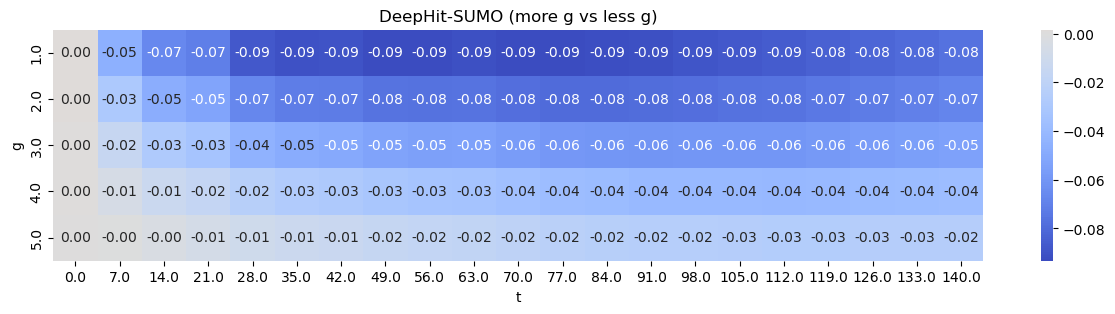

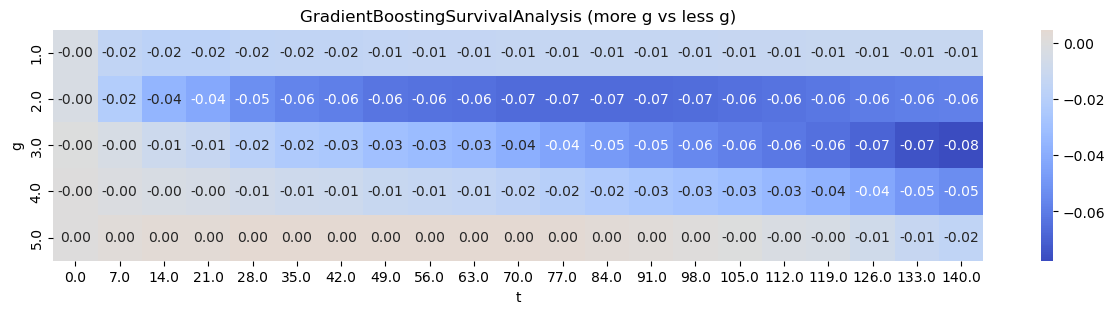

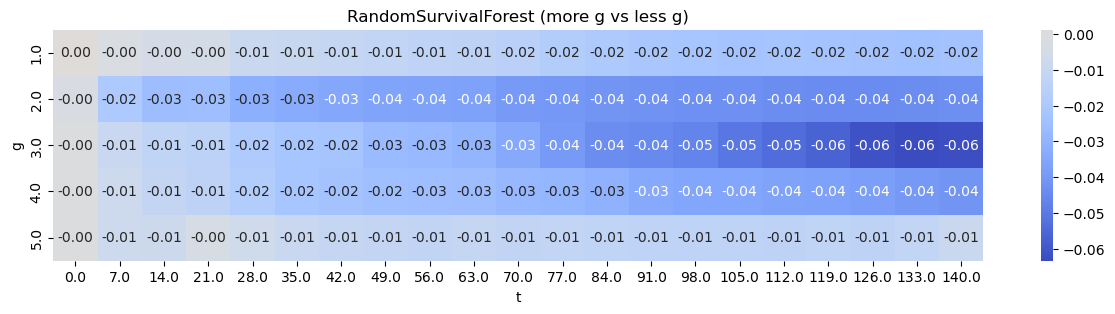

In [18]:
for grp, df_sub in df_comparsion_all.groupby('model_type'):
    df_to_plot = (
        df_sub.groupby(['t','g'])['pred_diff_more_g_vs_less_g'].apply(
            lambda x: x.mean()
        ).rename('diff').reset_index().pivot(
            index='g',
            columns='t',
            values='diff'
        )
    )
    fig, ax = plt.subplots(1,1, figsize=(15, 3))
    sns.heatmap(df_to_plot, center=0, annot=True, fmt='.2f', cmap='coolwarm')
    ax.set(title=f'{grp} (more g vs less g)')

    # fig.savefig(os.path.join(DIR_OUTPUT, f'mean_pred_vs_truth_LossSumo_{ds_name}.pdf'))

<Axes: xlabel='t', ylabel='g'>

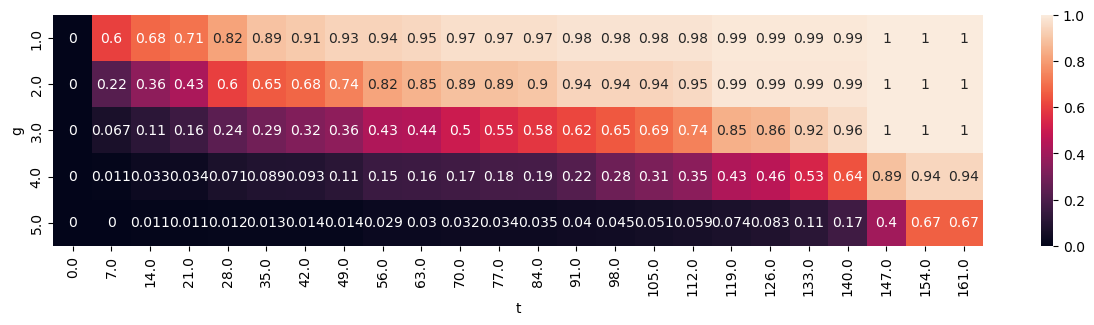

In [19]:
df_to_plot = df_truth.groupby(['t','g'])['truth'].apply(
    lambda x: x.sum()/x.notna().sum()
).rename('acc').reset_index().pivot(
    index='g',
    columns='t',
    values='acc'
)
fig, ax = plt.subplots(1,1, figsize=(15, 3))
sns.heatmap(df_to_plot, vmin=0,vmax=1, annot=True)
# fig.savefig(os.path.join(DIR_OUTPUT, f'mean_pred_vs_truth_LossSumoMoreG_{ds_name}.pdf'))

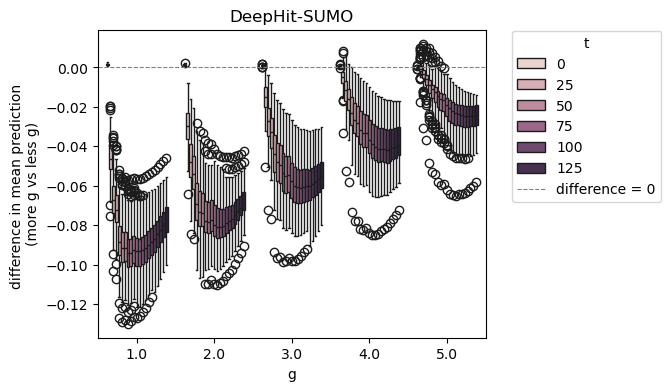

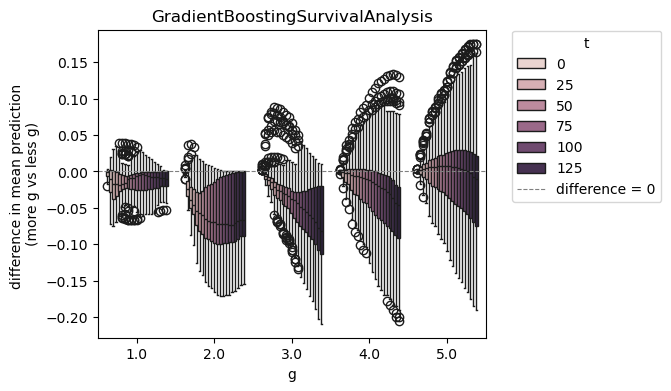

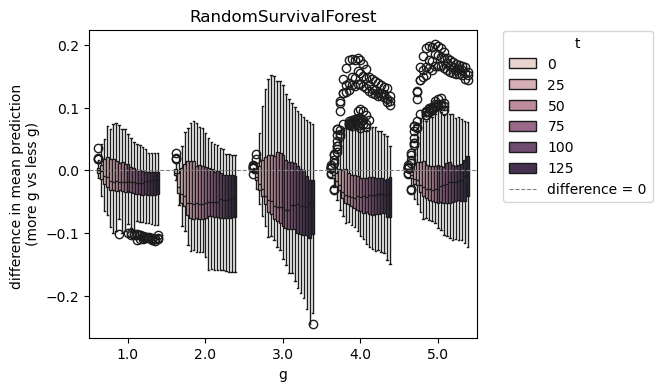

In [20]:
for grp, df_sub in df_comparsion_all.groupby('model_type'):

    fig, ax = plt.subplots(1,1, figsize=(5,4))
    sns.boxplot(
        data=df_sub,
        x='g',
        y='pred_diff_more_g_vs_less_g',
        hue='t',
        ax=ax
    )
    ax.set(ylabel='difference in mean prediction \n(more g vs less g)', title=grp)
    ax.axhline(y=0, ls='--', color='grey', lw=0.8, label='difference = 0')
    plt.legend(bbox_to_anchor = [1.05, 1.02], title='t')


# Clean up

In [21]:
with torch.no_grad():
    torch.cuda.empty_cache()
gc.collect()

56524